# Load in Libraries

The goal here is compare Andres' calculations of WSU data properties to my calculations to make sure we are getting the same numbers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, QTable, join
import astropy.units as u
import pandas as pd
import pickle
from importlib import reload
import wsu_plots
import wsu_db
import re

# Load in the Data

In [2]:
wsu_all = QTable.read('data/wsu_datarates_mit_per_mous_initial_goal_20250227.ecsv')

In [3]:
wsu_all.columns

<TableColumns names=('mous','proposal_id','schedblock_name','array','science_keyword','scientific_category','scientific_category_proposal','nant_typical','nant_array','nant_all','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_later_2x','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_later_2x','wsu_nspw_later_4x','wsu_specwidth_finest','wsu_chanavg_finest','wsu_velres_finest','wsu_specwidth_stepped','wsu_chanavg_stepped','wsu_velres_stepped','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_tint','wsu_nchan_spw_finest','wsu_nchan_spw_stepped','wsu_nchan_spw_stepped2','wsu_nchan_agg_finest_early','wsu_nchan_agg_finest_later_2x','wsu_nchan_agg_finest_later_4x','wsu_nchan_agg_stepped_early','wsu_nchan_agg_stepped_later_2x','wsu_nc

In [4]:
#andres = Table.read('andres_comparison/c9-c10_to_wsu_size_estimation.csv')
andres = Table.read('andres_comparison/c9-c10_science_asdm_size_estimation_by_asdm.csv')

In [5]:
andres.columns

<TableColumns names=('asdm_uid','sb_uid','sb_name','project_code','band_number','array_family','mous_status_uid','m5_wsu_bandwidth_mhz','tint_wsu','tint','m5_wsu_channel_number','m5_wsu_data_rate_gb_per_s','m5_wsu_size_gb','n_avg')>

In [6]:
aak_andres = join(wsu_all,andres,keys_left=('mous'),keys_right=('mous_status_uid'))

In [9]:
#aak_andres.write('andres_comparison/aak_andres_table_join_20250618.ecsv')
#aak_andres.write('andres_comparison/aak_andres_table_join_20250618.csv')

In [10]:
aak_andres.columns

<TableColumns names=('mous','proposal_id','schedblock_name','array','science_keyword','scientific_category','scientific_category_proposal','nant_typical','nant_array','nant_all','band','ntarget','s_fov','s_resolution','mosaic','imsize','pb','cell','blc_npol','blc_nspw','blc_specwidth','blc_freq','blc_velres','blc_nchan_agg','blc_nchan_max','blc_bandwidth_max','blc_bandwidth_agg','wsu_freq','wsu_npol','wsu_bandwidth_early','wsu_bandwidth_later_2x','wsu_bandwidth_later_4x','wsu_bandwidth_spw','wsu_nspw_early','wsu_nspw_later_2x','wsu_nspw_later_4x','wsu_specwidth_finest','wsu_chanavg_finest','wsu_velres_finest','wsu_specwidth_stepped','wsu_chanavg_stepped','wsu_velres_stepped','wsu_specwidth_stepped2','wsu_chanavg_stepped2','wsu_velres_stepped2','wsu_tint','wsu_nchan_spw_finest','wsu_nchan_spw_stepped','wsu_nchan_spw_stepped2','wsu_nchan_agg_finest_early','wsu_nchan_agg_finest_later_2x','wsu_nchan_agg_finest_later_4x','wsu_nchan_agg_stepped_early','wsu_nchan_agg_stepped_later_2x','wsu_nc

In [11]:
aak_andres['blc_productsize']

<Quantity [1.44757760e+00, 1.44757760e+00, 1.44757760e+00, 1.44757760e+00,
           1.44757760e+00, 1.44757760e+00, 1.44757760e+00, 1.44757760e+00,
           1.44757760e+00, 1.44757760e+00, 2.81021961e+03, 2.81021961e+03,
           2.81021961e+03, 1.97249824e+01, 1.97249824e+01, 1.97249824e+01,
           1.97249824e+01, 2.03636160e+00, 8.89344000e-02, 8.89344000e-02,
           8.89344000e-02, 8.89344000e-02, 8.89344000e-02, 8.89344000e-02,
           8.89344000e-02, 8.89344000e-02, 8.89344000e-02, 8.89344000e-02,
           8.89344000e-02, 8.89344000e-02, 8.89344000e-02, 8.89344000e-02,
           8.89344000e-02, 8.89344000e-02, 8.89344000e-02, 8.89344000e-02,
           8.89344000e-02, 8.89344000e-02, 8.89344000e-02, 8.89344000e-02,
           8.89344000e-02, 8.89344000e-02, 8.89344000e-02, 8.89344000e-02,
           1.41626880e+00, 1.65231360e+00, 2.36044800e-01, 2.36044800e-01,
           4.72089600e-01, 2.36044800e-01, 3.23635200e+00, 3.23635200e+00,
           3.23635200e+00

In [12]:
4.43*0.15

0.6645

Text(0, 0.5, 'n_avg / aak_wsu_chanavg_stepped2')

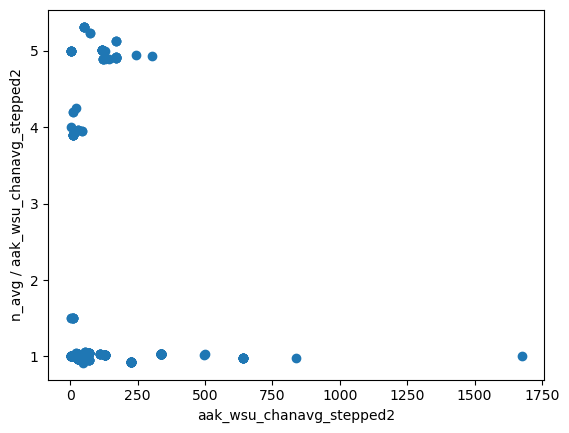

In [13]:
plt.scatter(aak_andres['wsu_chanavg_stepped2'], aak_andres['n_avg']/aak_andres['wsu_chanavg_stepped2'])
plt.xlabel('aak_wsu_chanavg_stepped2')
plt.ylabel('n_avg / aak_wsu_chanavg_stepped2')

In [14]:
idx = (aak_andres['wsu_chanavg_stepped2'] < 250) & (aak_andres['n_avg']/aak_andres['wsu_chanavg_stepped2'] > 3) & (aak_andres['n_avg']/aak_andres['wsu_chanavg_stepped2'] < 4)
aak_andres[idx]['proposal_id','mous','schedblock_name','wsu_freq','blc_specwidth','blc_velres','wsu_chanavg_stepped2','n_avg','wsu_velres_stepped2','wsu_specwidth_stepped2']

proposal_id,mous,schedblock_name,wsu_freq,blc_specwidth,blc_velres,wsu_chanavg_stepped2,n_avg,wsu_velres_stepped2,wsu_specwidth_stepped2
,,,GHz,kHz,km / s,,,km / s,kHz
str14,str22,str26,float64,float64,float64,float64,float64,float64,float64
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0
2021.1.00769.S,uid://A001/X1590/X1c0f,DYNAMO_D_a_07_TM1,326.41524737610416,282.0373313190409,0.26516195563437556,10.0,39.0,0.12398925036540075,135.0


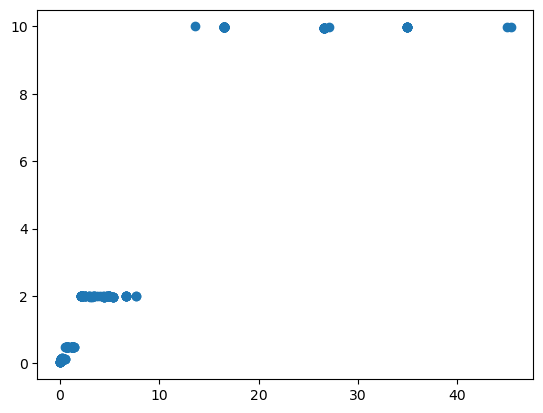

In [16]:
plt.scatter(aak_andres['blc_velres'],aak_andres['wsu_velres_stepped2'])

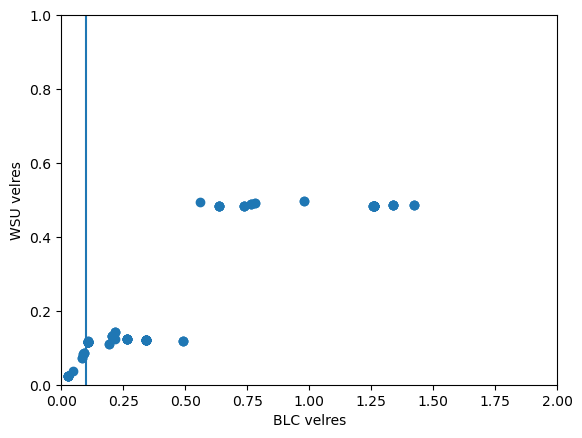

In [17]:
plt.scatter(aak_andres['blc_velres'],aak_andres['wsu_velres_stepped2'])
plt.xlim(0,2)
plt.ylim(0,1)
plt.xlabel('BLC velres')
plt.ylabel('WSU velres')
plt.axvline(0.1)

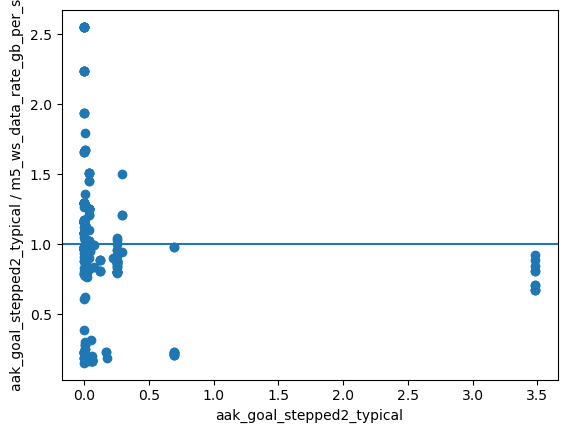

In [18]:
plt.scatter(aak_andres['wsu_datarate_goal_stepped2_typical'], aak_andres['m5_wsu_data_rate_gb_per_s']/aak_andres['wsu_datarate_goal_stepped2_typical'])
plt.xlabel('aak_goal_stepped2_typical')
plt.ylabel('aak_goal_stepped2_typical / m5_ws_data_rate_gb_per_s')
plt.axhline(1.0)

In [19]:
idx = aak_andres['wsu_datarate_goal_stepped2_typical'].value > 3.0
aak_andres[idx]['proposal_id','mous','schedblock_name','wsu_freq','blc_specwidth','blc_velres','wsu_chanavg_stepped2','n_avg','wsu_velres_stepped2','wsu_specwidth_stepped2']

proposal_id,mous,schedblock_name,wsu_freq,blc_specwidth,blc_velres,wsu_chanavg_stepped2,n_avg,wsu_velres_stepped2,wsu_specwidth_stepped2
,,,GHz,kHz,km / s,,,km / s,kHz
str14,str22,str26,float64,float64,float64,float64,float64,float64,float64
2021.1.00450.S,uid://A001/X1590/X2360,HOPS_400_a_03_TM1,111.82534899097573,30.52622624603702,0.08145155072234114,2.0,3.0,0.07238427099971058,27.0
2021.1.00450.S,uid://A001/X1590/X2360,HOPS_400_a_03_TM1,111.82534899097573,30.52622624603702,0.08145155072234114,2.0,3.0,0.07238427099971058,27.0
2021.1.01123.L,uid://A001/X15a1/X1a5d,HD_13534_a_07_TM1,337.7012453061301,30.517013335619307,0.026462336931617966,2.0,10.0,0.023969104285245783,27.0
2021.1.01123.L,uid://A001/X15a1/X1a5d,HD_13534_a_07_TM1,337.7012453061301,30.517013335619307,0.026462336931617966,2.0,10.0,0.023969104285245783,27.0
2021.1.01123.L,uid://A001/X15a1/X1a71,RXJ1615._a_07_TM1,337.7039561384439,30.516501322589168,0.02646168125807957,2.0,10.0,0.023968911879378902,27.0
2021.1.01123.L,uid://A001/X15a1/X1a71,RXJ1615._a_07_TM1,337.7039561384439,30.516501322589168,0.02646168125807957,2.0,10.0,0.023968911879378902,27.0
2021.1.01123.L,uid://A001/X15a1/X1a71,RXJ1615._a_07_TM1,337.7039561384439,30.516501322589168,0.02646168125807957,2.0,10.0,0.023968911879378902,27.0
2021.1.01123.L,uid://A001/X15a1/X1a79,RXJ1842._a_07_TM1,337.7022649594735,30.5149303128904,0.026460454918797113,2.0,10.0,0.023969031913278344,27.0


In [28]:
mous_list = ['uid://A001/X158f/Xa09','uid://A001/X146c/X12','uid://A001/X146c/Xe','uid://A001/X158f/Xa19',
             'uid://A001/X1465/X1631','uid://A001/X158f/Xa1d','uid://A001/X1465/X162d','uid://A001/X158f/Xa0d',
             'uid://A001/X1590/X2360','uid://A001/X1590/X26c4']
for mous in mous_list:
    idx = wsu_all['mous'] == mous
    print(wsu_all[idx]['mous','wsu_chanavg_stepped2','wsu_freq','wsu_velres_stepped2'])

         mous         wsu_chanavg_stepped2      wsu_freq      wsu_velres_stepped2
                                                  GHz                km / s      
--------------------- -------------------- ------------------ -------------------
uid://A001/X158f/Xa09                  2.0 104.24027490072169 0.07765133364919742
        mous         wsu_chanavg_stepped2      wsu_freq     wsu_velres_stepped2
                                                 GHz               km / s      
-------------------- -------------------- ----------------- -------------------
uid://A001/X146c/X12                  2.0 113.9807615555354  0.0710154613421856
        mous        wsu_chanavg_stepped2      wsu_freq      wsu_velres_stepped2
                                                GHz                km / s      
------------------- -------------------- ------------------ -------------------
uid://A001/X146c/Xe                  2.0 104.28893681642722 0.07761510101735929
         mous         wsu_chanav

In [25]:
idx = wsu_all['mous'] == "uid://A001/X146c/X12"
wsu_all[idx]['wsu_chanavg_stepped2','wsu_freq','wsu_velres_stepped2']

wsu_chanavg_stepped2,wsu_freq,wsu_velres_stepped2
,GHz,km / s
float64,float64,float64
2.0,113.9807615555354,0.0710154613421856
